In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


**Load python libraries**> 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import xgboost as XGBRegressor
from sklearn import metrics


Help fuction to plot the result distribution

In [4]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="#8ab9eb", label="Actual Value")
    sns.distplot(yhat, hist=False, color="#0779f2", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('SalePrice')
    plt.ylabel('Sales Proportion ')

    plt.show()
    plt.close()

Read the dataset

In [5]:
df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

In [6]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Data Cleaning and Wrangling
Here, we'll check if there's missing value, duplicates, etc...

#### Removed duplicated values

In [7]:
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Check the null value

In [9]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
df.drop(['Id'], axis=1, inplace=True)

In [11]:
df.duplicated().sum()

0

There is no duplicated in the dataset

In [12]:
#Display all the unique containt in each column

for col in df.describe(include='object').columns:
    print(col)
    print(df[col].value_counts())
    print('-'*50)

MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
--------------------------------------------------
Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
--------------------------------------------------
Alley
Alley
Grvl    50
Pave    41
Name: count, dtype: int64
--------------------------------------------------
LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
--------------------------------------------------
LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
--------------------------------------------------
Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
--------------------------------------------------
LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
--------------------------------------------------
LandS

In [13]:
data_n = df.select_dtypes(include = ['float64', 'int64'])
#data_n = data.ffill() #fille the na value


df_num_corr = data_n.corr()['SalePrice'] # -1 means that the latest row is price
top_features = df_num_corr[abs(df_num_corr) > 0.5].sort_values(ascending=False) #displays pearsons correlation coefficient 
print("There is {} strongly correlated values with price:\n{}".format(len(top_features), top_features))

There is 11 strongly correlated values with price:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [14]:
print('Total numll value', data_n.isna().sum())

Total numll value MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64


In [15]:
data_n['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Fill the null values in numerical and categorical columns

In [16]:
#categorical columns fill with other 
for col in data_n.select_dtypes(include='object').columns:
    data_n[col].fillna('Other', inplace=True)

#numerical columns fill with average values
for col in data_n.select_dtypes(exclude='object').columns:
    data_n[col].fillna(data_n[col].mean(), inplace=True)


EDA

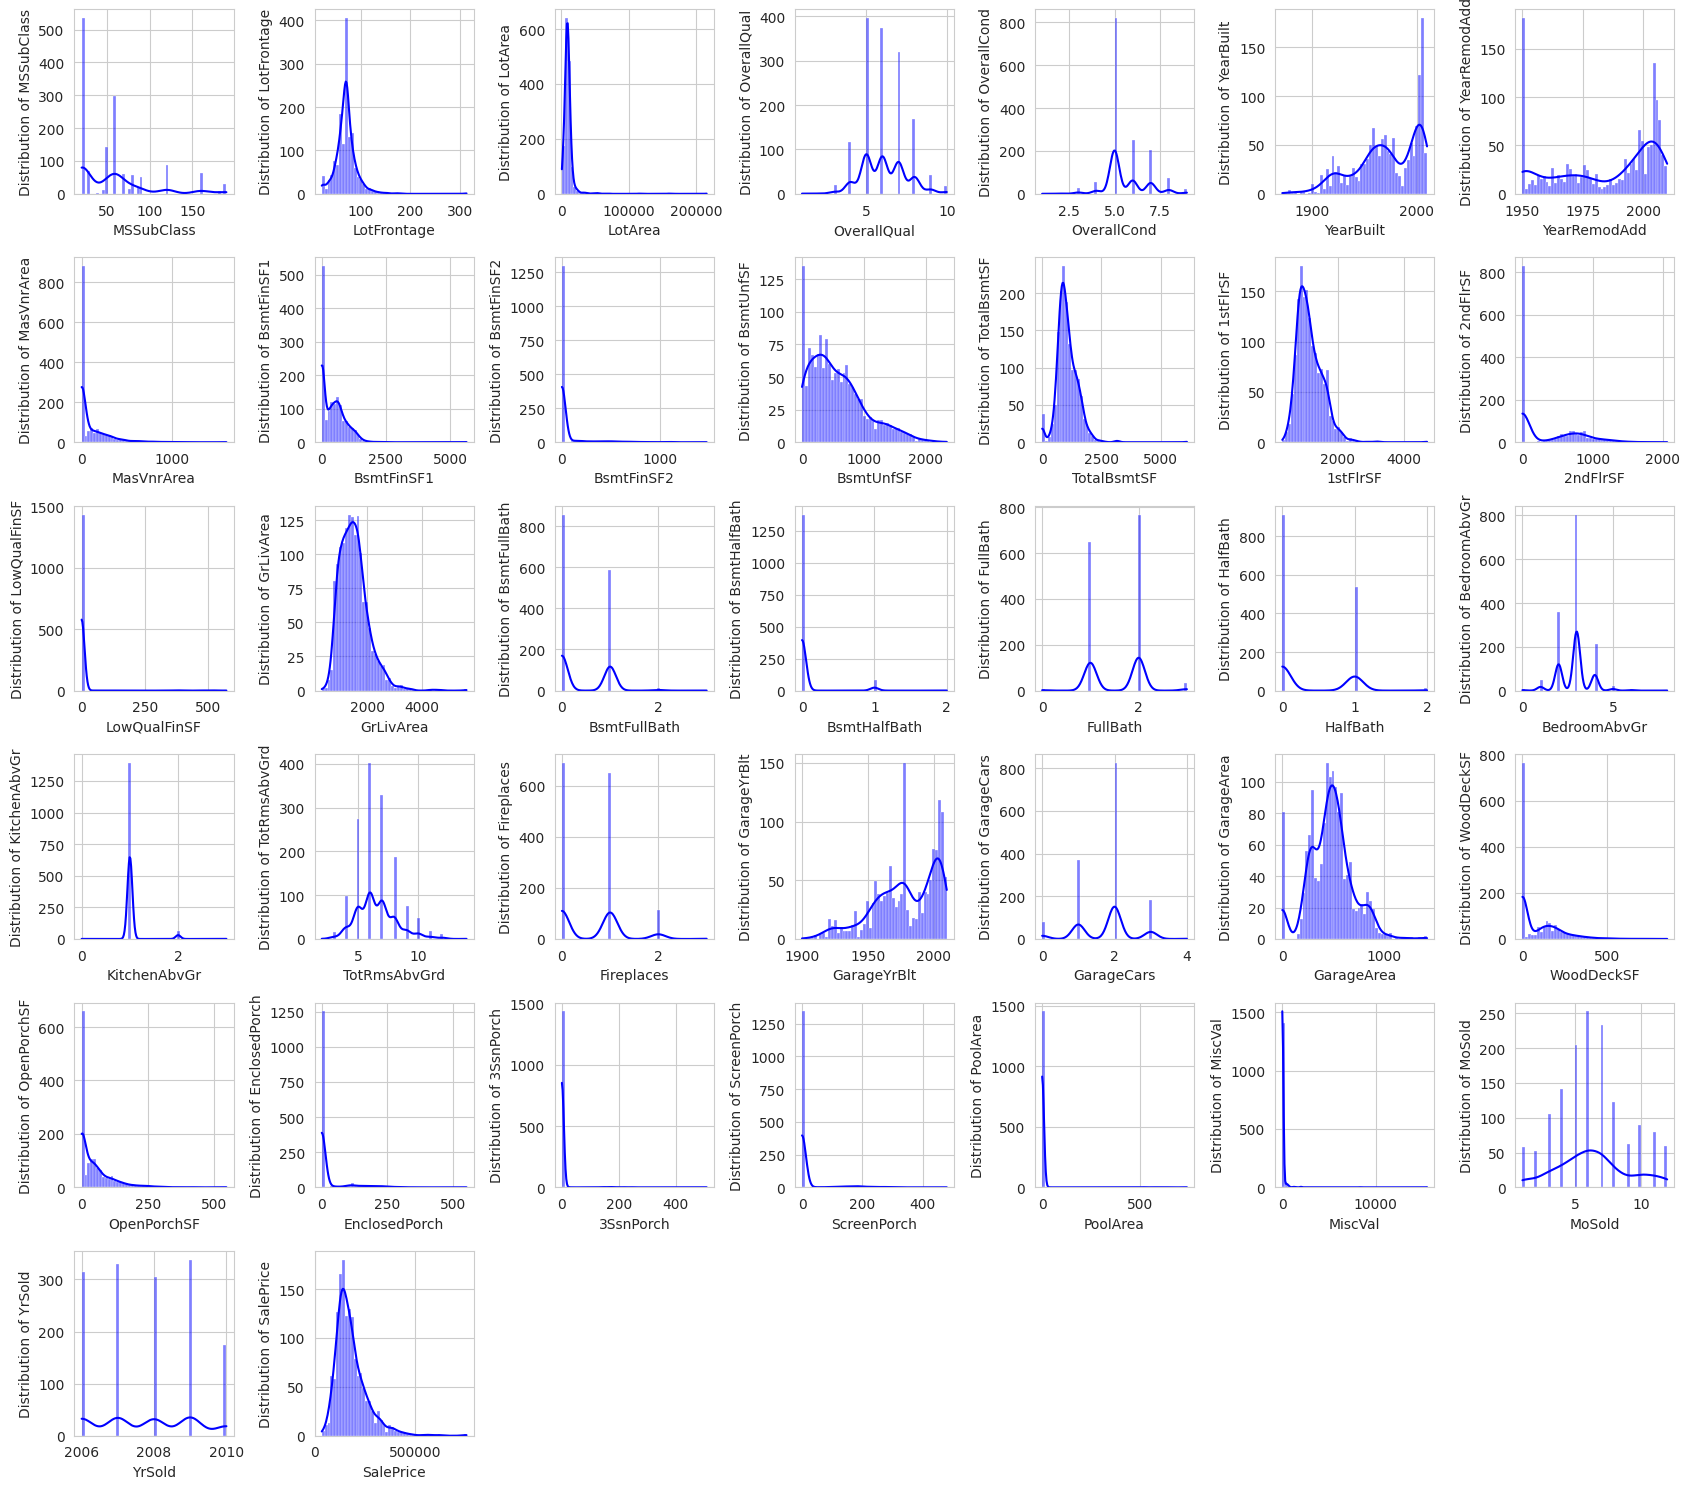

In [17]:
sns.set_style("whitegrid")

plt.figure(figsize=(17, 15))

# Loop through numerical features
for i, column in enumerate(data_n, start=1):  # Use enumerate to get the index
    plt.subplot(6, 7, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data_n[column], bins=50, kde=True, color='blue')
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()

### Plot heatmap correlation matrix

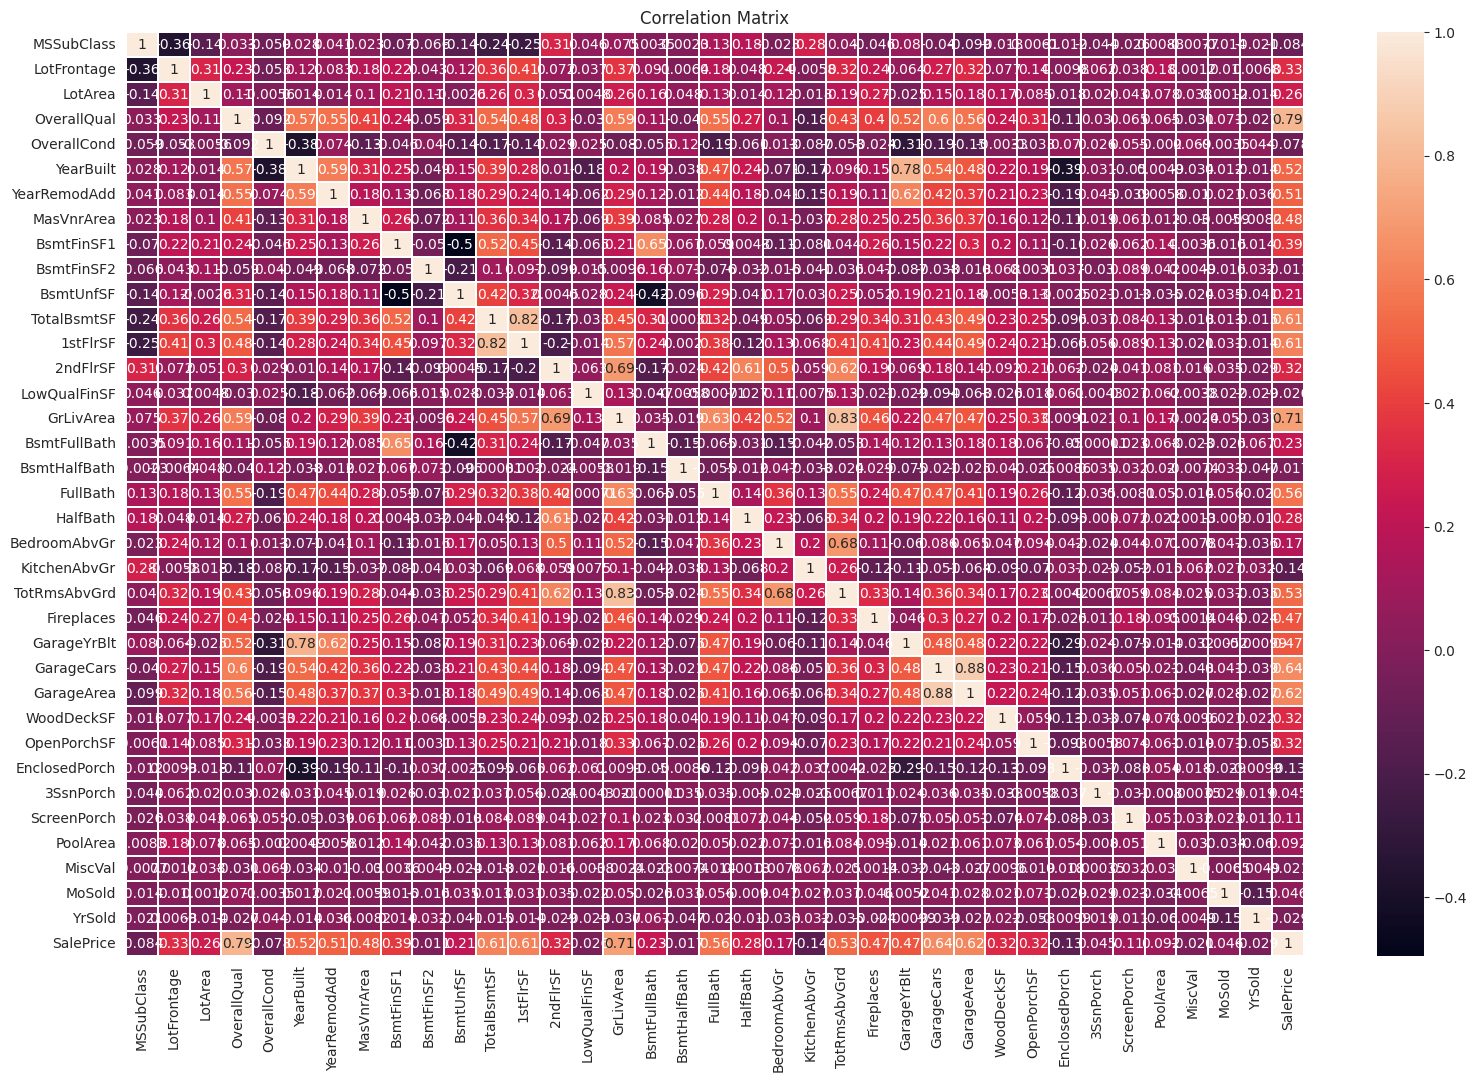

In [18]:
#Plot correlation matrix
corr = data_n.corr()
plt.figure(figsize=(19,12))
sns.heatmap(corr, annot=True, linewidth=0.02)
plt.title("Correlation Matrix")
plt.show()

## Sales distributions

<Axes: xlabel='SalePrice', ylabel='Count'>

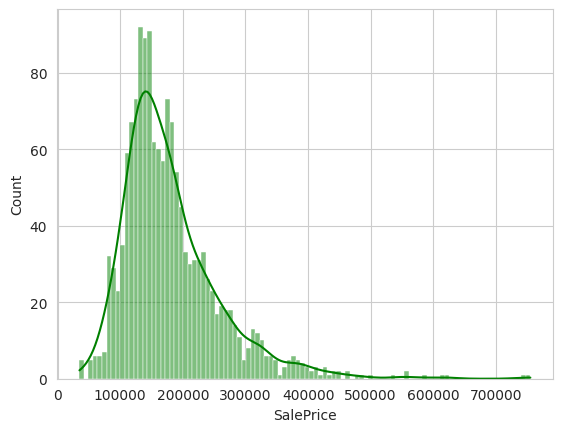

In [19]:
#data_n['SalePrice'] = np.log(data_n['SalePrice'])

sns.histplot(data=data_n, x='SalePrice', bins=100, kde=True, color='g')

## Data Preparation

Let's first split our data into `X` features and `y` target.

In [20]:
X = data_n.drop('SalePrice',axis=1)
y = data_n.SalePrice

Now that we have split our data into training and testing sets, the training data is used for your model to recognize patterns using some criteria,the test data set it used to evaluate your model, as shown in the following image:

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("number of test samples :", X_test.shape[0])
print("number of training samples:",X_train.shape[0])


number of test samples : 438
number of training samples: 1022


In [22]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Initialize an empty list to store the scores
scores = []

# Create an instance of the LinearRegression model
lr = LinearRegression()

# Define the number of splits for KFold
kf = KFold(n_splits=5, shuffle=True, random_state=72018)

# Loop through the splits provided by the cross-validator (kf)
for train_index, test_index in kf.split(X):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit the model on the training data
    lr.fit(X_train, y_train)
        
    # Predict on the test data
    y_pred = lr.predict(X_test)

    # Calculate the R² score for the predictions
    score = r2_score(y_test, y_pred)
    
    # Append the score to the list
    scores.append(score)
    
# Display the scores
scores

[0.8161110768071864,
 0.7969538813970176,
 0.7948712595949334,
 0.6197925377934688,
 0.8383420957332203]

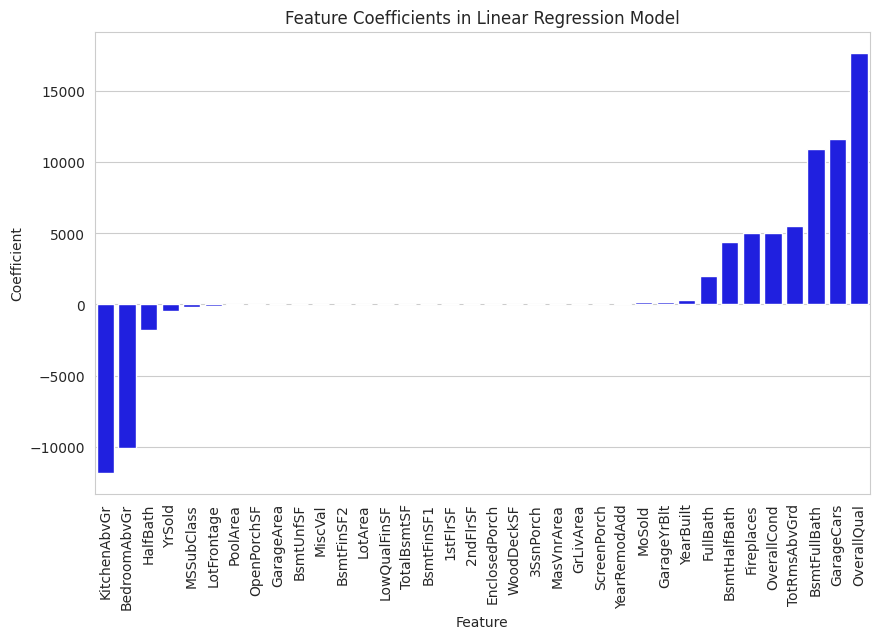

In [23]:
# Assuming lr is your fitted linear regression model and X is your feature DataFrame
coef = lr.coef_  # Get the coefficients from the linear regression model
column = X.columns  # Get the feature names

# Create a DataFrame with feature names and their corresponding coefficients
df_ = pd.DataFrame({'Feature': column, 'Coefficient': coef})

# Reset the index if needed (not necessary here since we are creating a new DataFrame)
df_ = df_.reset_index(drop=True).sort_values(by='Coefficient')

# Plotting
plt.figure(figsize=(10, 6))  # Optional: to make the plot larger
sns.barplot(data=df_, x='Feature', y='Coefficient', color='b')
plt.title('Feature Coefficients in Linear Regression Model')
plt.xticks(rotation=90)  # Optional: to rotate feature names if they're too long
plt.show()


In [24]:
# Assuming X_train, y_train, X_test, y_test are already defined

# Create and fit the linear regression model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Make predictions on the test set
predicted = lm.predict(X_test)

# Calculate the R^2 score on the training data
r2_train = lm.score(X_train, y_train)
print("R^2 on training data:", r2_train)

# Calculate the R^2 score on the test data
r2_test = r2_score(y_test, predicted)
print("R^2 on test data:", r2_test)

# Calculate the RMSE on the test data
rms = np.sqrt(mean_squared_error(y_test, predicted))
print('RMSE on test data:', rms)


R^2 on training data: 0.8058800330518529
R^2 on test data: 0.8383420957332203
RMSE on test data: 30757.64824671864


We can plot distributions of the predicted values versus the actual values.

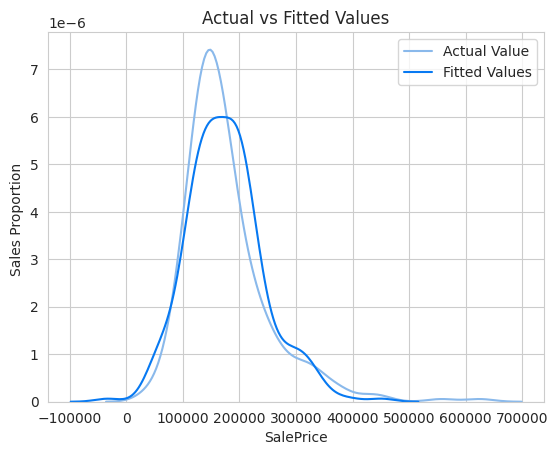

In [25]:
plot_dis(y_test,predicted)

## XGBRegressor Model GridSearchCV

In [26]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import numpy as np

# Assuming X_train and y_train are already defined

# Create the parameter grid: gbm_param_grid
gbm_param_grid = {
    'colsample_bytree': [0.3, 0.7],
    'n_estimators': [50],
    'max_depth': [2, 5],
    'learning_rate': [0.001, 0.01, 0.05, 0.1]
}

# Instantiate the regressor: gbm
gbm = xgb.XGBRegressor()

# Perform grid search: grid_mse
grid_mse = GridSearchCV(param_grid=gbm_param_grid, estimator=gbm, 
                        scoring='neg_mean_squared_error', verbose=1)

# Fit grid_mse to the data
grid_mse.fit(X_train, y_train)

# Print the best parameters and lowest RMSE
print("Best parameters found: ", grid_mse.best_params_)
print("Lowest RMSE found: ", np.sqrt(np.abs(grid_mse.best_score_)))



Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Lowest RMSE found:  31851.06796493758


In [27]:
pred_xgb = grid_mse.predict(X_test)

#Let's calculate the r2_score() on both, training and testing data sets.
# Evaluate the model
mse = mean_squared_error(y_test, pred_xgb)
r2 = r2_score(y_test, pred_xgb)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 488977592.5105716
R-squared: 0.9164436134368308


In [28]:
def compare(y_test, pred_xgb) :
  compare = pd.DataFrame()
  compare["Actual"] = y_test
  compare["Predict"] = pred_xgb

  return compare

In [29]:
compare(y_test, pred_xgb)

,Actual,Predict
8,129900,174214.421875
10,129500,132971.984375
11,345000,342285.781250
13,279500,224328.390625
14,157000,151834.468750
...,...,...
1440,191000,207017.843750
1442,310000,331552.406250
1446,157900,147277.562500
1451,287090,243181.984375


## Decision Tree Regressor

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the model
model = DecisionTreeRegressor(random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 1430822834.8652968
R-squared: 0.7949550573719009


## Random forest regression

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the Random Forest Regressor
rfc = RandomForestRegressor()  # You can adjust n_estimators as needed

forest_params = [{'max_depth': list(range(1, 15)), 'max_features': list(range(1, 14))}]

# Fit the model to the training data with GridSearchCV
clf = GridSearchCV(rfc, forest_params, scoring='r2')  # Use an appropriate scoring metric

clf.fit(X_train, y_train)

# Make predictions on the training set
pred_ = clf.predict(X_train)

# Display the predictions
print(pred_)


[173764.61025578 146451.37972583 210492.46621947 ... 118336.00866446
 172225.38494976 181587.63652801]


In [32]:
import numpy as np
from sklearn import metrics

def Evaluation(X_test, y_test, clf):
    # Print the best parameters
    #print("Best parameters found: ", clf.best_params_)

    # Make predictions on the test set
    # Make predictions on the training set
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate evaluation metrics
    mse = metrics.mean_absolute_error(y_test, y_pred)
    msqe = metrics.mean_squared_error(y_test, y_pred)
    r2_score = metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(msqe)
    
    # Print evaluation metrics
    print("Mean Absolute Error: ", mse)
    print("Mean Squared Error: ", msqe)
    print("Root Mean Squared Error: ", rmse)
    print("R2 Score: ", r2_score)


 Now can use the Evaluation function with test data 

In [33]:
Evaluation(X_test,y_test, clf)

Mean Absolute Error:  16295.455537858332
Mean Squared Error:  680519403.6013637
Root Mean Squared Error:  26086.766829206023
R2 Score:  0.9024777500969319


## Submission
predict on the competition test data using the xgb GridSearchCV fitted model

In [34]:
# Load the test dataset
test_file_path = "../input/house-prices-advanced-regression-techniques/test.csv"
test_data = pd.read_csv(test_file_path)

# Select numerical columns
test_data = test_data.select_dtypes(include=['float64', 'int64'])

# Pop the 'Id' column
ids = test_data.pop('Id')

# Make predictions (assuming grid_mse is a pre-trained model)
prediction = grid_mse.predict(test_data)

# Create a DataFrame for the output
output = pd.DataFrame({
    'Id': ids,
    'SalePrice': prediction
})



In [35]:

sample_sub_df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")
output.to_csv('submission.csv',index=False)

In [36]:
# Display the first few rows of the output
print(output.head())


     Id      SalePrice
0  1461  128396.843750
1  1462  161901.703125
2  1463  178572.171875
3  1464  184306.093750
4  1465  181789.078125
